<a href="https://colab.research.google.com/github/moiz-shahid/Deep-Learning-Tutorials/blob/main/Tutorial-02-MLP/DL_Tutorial_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Scale data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
configurations = [
    (5,),
    (10,),
    (10, 10),
    (20, 10),
    (20, 20),
    (20, 20, 10)
]

In [7]:
results = []

for config in configurations:

    mlp = MLPClassifier(
        hidden_layer_sizes=config,
        max_iter=1000,
        random_state=42,
        learning_rate_init=0.001
    )

    mlp.fit(X_train_scaled, y_train)

    y_pred = mlp.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    results.append(
        [config, accuracy, mlp.n_iter_]
    )

    print("Configuration:", config)
    print("Accuracy:", accuracy)
    print("Epochs:", mlp.n_iter_)
    print("----------------------")

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Configuration: (5,)
Accuracy: 1.0
Epochs: 1000
----------------------


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Configuration: (10,)
Accuracy: 1.0
Epochs: 1000
----------------------
Configuration: (10, 10)
Accuracy: 1.0
Epochs: 609
----------------------
Configuration: (20, 10)
Accuracy: 1.0
Epochs: 470
----------------------
Configuration: (20, 20)
Accuracy: 1.0
Epochs: 526
----------------------
Configuration: (20, 20, 10)
Accuracy: 1.0
Epochs: 354
----------------------


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


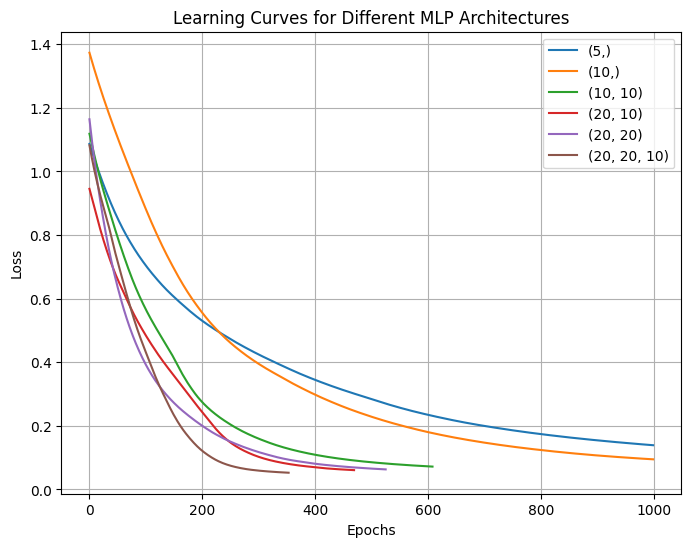

In [8]:
plt.figure(figsize=(8, 6))

for config in configurations:

    mlp = MLPClassifier(
        hidden_layer_sizes=config,
        max_iter=1000,
        random_state=42,
        learning_rate_init=0.001
    )

    mlp.fit(X_train_scaled, y_train)

    plt.plot(
        mlp.loss_curve_,
        label=str(config)
    )

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Curves for Different MLP Architectures")
plt.legend()
plt.grid()
plt.show()

In [13]:
import pandas as pd

architecture_results = pd.DataFrame(
    results,
    columns=[
        "Hidden Layers",
        "Accuracy",
        "Epochs"
    ]
)

architecture_results

,Hidden Layers,Accuracy,Epochs
0,"(5,)",1.0,1000
1,"(10,)",1.0,1000
2,"(10, 10)",1.0,609
3,"(20, 10)",1.0,470
4,"(20, 20)",1.0,526
5,"(20, 20, 10)",1.0,354


## Task 1 Conclusion

All tested architectures achieved an accuracy of 100%, so increasing
the number of hidden layers or neurons did not improve the test
accuracy for this dataset.

However, the architecture affected convergence speed. The models with
one hidden layer containing 5 or 10 neurons reached the maximum limit
of 1000 epochs without fully converging. Deeper networks converged in
fewer epochs.

Among the tested configurations, (20, 20, 10) gave the best result in
terms of convergence speed, achieving 100% accuracy in only 354 epochs.

# Task 2

In [9]:
hidden_layer_sizes=(10, 10)

In [10]:
learning_rates = [
    0.0001,
    0.001,
    0.01,
    0.1
]

In [11]:
lr_results = []

for lr in learning_rates:

    mlp = MLPClassifier(
        hidden_layer_sizes=(10, 10),
        max_iter=2000,
        random_state=42,
        learning_rate_init=lr
    )

    mlp.fit(X_train_scaled, y_train)

    y_pred = mlp.predict(X_test_scaled)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    lr_results.append(
        [lr, accuracy, mlp.n_iter_]
    )

    print("Learning Rate:", lr)
    print("Accuracy:", accuracy)
    print("Epochs:", mlp.n_iter_)
    print("Final Loss:", mlp.loss_curve_[-1])
    print("----------------------")

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.0001
Accuracy: 1.0
Epochs: 2000
Final Loss: 0.26012031423949583
----------------------
Learning Rate: 0.001
Accuracy: 1.0
Epochs: 609
Final Loss: 0.07180137907334191
----------------------
Learning Rate: 0.01
Accuracy: 1.0
Epochs: 157
Final Loss: 0.04936885961217034
----------------------
Learning Rate: 0.1
Accuracy: 0.9555555555555556
Epochs: 159
Final Loss: 0.001067833889792831
----------------------


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


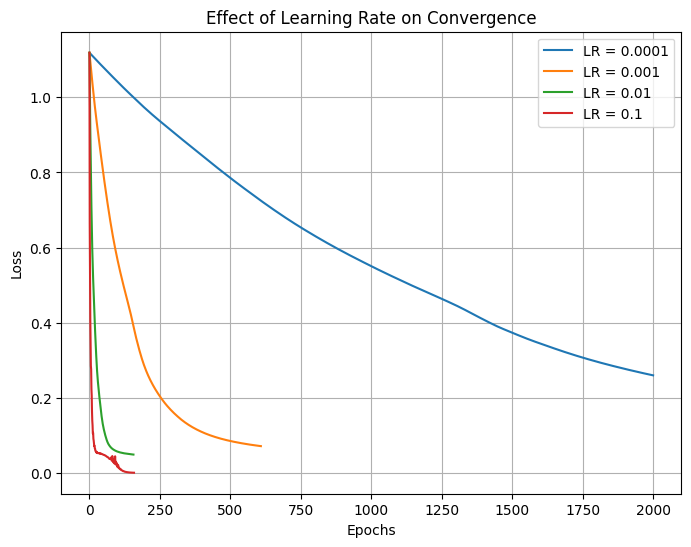

In [12]:
plt.figure(figsize=(8, 6))

for lr in learning_rates:

    mlp = MLPClassifier(
        hidden_layer_sizes=(10, 10),
        max_iter=2000,
        random_state=42,
        learning_rate_init=lr
    )

    mlp.fit(X_train_scaled, y_train)

    plt.plot(
        mlp.loss_curve_,
        label=f"LR = {lr}"
    )

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.grid()
plt.show()

In [14]:
learning_rate_results = pd.DataFrame(
    lr_results,
    columns=[
        "Learning Rate",
        "Accuracy",
        "Epochs"
    ]
)

learning_rate_results

,Learning Rate,Accuracy,Epochs
0,0.0001,1.000000,2000
1,0.0010,1.000000,609
2,0.0100,1.000000,157
3,0.1000,0.955556,159


## Task 2 Conclusion

The learning rate had a significant effect on convergence.

A very small learning rate of 0.0001 resulted in slow learning and
reached the maximum limit of 2000 epochs without convergence.

Increasing the learning rate to 0.001 reduced the number of epochs to
609 while maintaining 100% accuracy.

A learning rate of 0.01 converged much faster, requiring only 157
epochs while still achieving 100% accuracy.

Although a learning rate of 0.1 produced a very low final training
loss, the test accuracy decreased to approximately 95.56%.

Therefore, a learning rate of 0.01 provided the best balance between
convergence speed and model performance in this experiment.